<a href="https://colab.research.google.com/github/jxy-ygjm/EC1B1-Coursework/blob/main/EC1B1_Code_ipynb_Group_55.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC1B1 Coursework

**Winter Term 2025/2026**

<div style="font-family: system-ui; padding: 20px 30px 20px 20px; background-color: #FFFFFF; border-left: 8px solid #0570b0; border-radius: 8px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);max-width:600px;color:#212121;">

**Coursework Notebook**
- Group 55
    - Xuanyang Ji
    - Felix Kalu
    - Rishi Ganiger
- Date: 28/02/2026

</div>

**Importing libraries**

To run the notebook, we first need to import all the libraries below

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


## Section 3: Data Cleaning

### Section 3.2: Cleaning the data

The raw data are stored on [GitHub](https://github.com/jxy-ygjm/EC1B1-Coursework), allowing easier data import.

We store all the raw data in a dictionary, so we can easily handle procedures like merge

In [ ]:
# Raw URL of data
raw_url = (
    "https://raw.githubusercontent.com/jxy-ygjm/EC1B1-Coursework/main/data/raw/"
)

# Specific data name
data_name = [
    "consumer_price", "exchange_rate", "industrial_production",
    "international_reserves"
]

In [ ]:
# Create empty dictionary storing data
data = {}

# Read data
for name in data_name:
    data[name] = pd.read_csv(raw_url + name + ".csv")

Now, we try to investigate the dataframes

In [ ]:
for value in data.values():
    print(value.columns)

Index(['COUNTRY', 'INDEX_TYPE', 'COICOP_1999', 'TYPE_OF_TRANSFORMATION',
       'FREQUENCY', 'TIME_PERIOD', 'OBS_VALUE', 'SCALE'],
      dtype='object')
Index(['COUNTRY', 'INDICATOR', 'TYPE_OF_TRANSFORMATION', 'FREQUENCY',
       'TIME_PERIOD', 'OBS_VALUE', 'SCALE'],
      dtype='object')
Index(['COUNTRY', 'PRODUCTION_INDEX', 'TYPE_OF_TRANSFORMATION', 'FREQUENCY',
       'TIME_PERIOD', 'OBS_VALUE', 'SCALE'],
      dtype='object')
Index(['COUNTRY', 'INDICATOR', 'UNIT', 'FREQUENCY', 'TIME_PERIOD', 'OBS_VALUE',
       'SCALE'],
      dtype='object')


We can see that only the `COUNTRY`, `TIME_PERIOD` and `OBS_VALUE` are useful to us.

We can now clean the data and merge them

In [ ]:
# Set a list for clean data
cleaned = []

for name, df in data.items():
    temp = (df[["COUNTRY", "TIME_PERIOD", "OBS_VALUE"]]
            .copy()
            .rename(columns={"OBS_VALUE": name})
            .set_index(["COUNTRY", "TIME_PERIOD"])
    )
    cleaned.append(temp)

df = pd.concat(cleaned, axis=1)

In [ ]:
# Investigate the dataframe
df.head()

consumer_price  exchange_rate  industrial_production  \
COUNTRY TIME_PERIOD                                                         
Spain   1959-M12           2.525752           60.0                    NaN   
        1960-M01           2.505928           60.0                    NaN   
        1960-M02           2.503895           60.0                    NaN   
        1960-M03           2.500846           60.0                    NaN   
        1960-M04           2.502879           60.0                    NaN   

                     international_reserves  
COUNTRY TIME_PERIOD                          
Spain   1959-M12                      200.0  
        1960-M01                      233.0  
        1960-M02                      253.0  
        1960-M03                      299.0  
        1960-M04                      326.0

As `consumer_price`, `exchange_rate` and `industrial_production` are indices or have direct meaning, we do not need to know their scale, but for international_reserves, as its nominal measure, we need to know its scale

In [ ]:
data["international_reserves"]["SCALE"].head()

,SCALE
0,Millions
1,Millions
2,Millions
3,Millions
4,Millions


Can see all the data are in Millions scale, we can rename the column to highlight this

In [ ]:
df = df.rename(
    columns={"international_reserves": "international_reserves (M)"}
)

In [ ]:
# See dataframe
df

consumer_price  exchange_rate  \
COUNTRY       TIME_PERIOD                                  
Spain         1959-M12           2.525752           60.0   
              1960-M01           2.505928           60.0   
              1960-M02           2.503895           60.0   
              1960-M03           2.500846           60.0   
              1960-M04           2.502879           60.0   
...                                   ...            ...   
United States 1990-M08          60.351608            NaN   
              1990-M09          60.856066            NaN   
              1990-M10          61.222946            NaN   
              1990-M11          61.360525            NaN   
              1990-M12          61.360525            NaN   

                           industrial_production  international_reserves (M)  
COUNTRY       TIME_PERIOD                                                     
Spain         1959-M12                       NaN                  200.000000  
              1960-M01                       NaN                  233.000000  
              1960-M02                       NaN                  253.000000  
              1960-M03                       NaN                  299.000000  
              1960-M04                       NaN                  326.000000  
...                                          ...                         ...  
United States 1990-M08                       NaN                78908.838357  
              1990-M09                       NaN                80024.166133  
              1990-M10                       NaN                82852.196532  
              1990-M11                       NaN                83059.402774  
              1990-M12                       NaN                83316.214608  

[746 rows x 4 columns]

#### The monthly growth in the nominal exchange rate

The IMF provides the nominal exchange rate as National Currency per US Dollar (period average)

This means Eₜ is defined as domestic currency per 1 USD, i.e. Spain currency / USD

Therefore, a higher Eₜ means a depreciation of Spain currency and an appreciation of USD

In [ ]:
# Construct nominal exchange rate growth for Spain
df["nominal_exchange_rate_growth"] = (
    np.log(df["exchange_rate"])
    .groupby(level="COUNTRY")
    .diff()
)

There is no exchange rate data for US so `groupby` will not result error

#### The monthly inflation rate
Here we create monthly inflation rate first as it helps to construct monthly growth in the real exchange rate

In [ ]:
# Construct monthly inflation rate for both Spain and the US
df["inflation"] = (
    np.log(df["consumer_price"])
    .groupby(level="COUNTRY")
    .diff()
)

#### The monthly growth in the real exchange rate

As our nominal exchange rate is in the format of Spain currency / USD, so to calculate real exchange rate, we can use

ϵ = (E × Pᵤ) / Pₛ

where Pᵤ is the price level in US, and Pₛ is the price level in Spain

Then for the monthly growth in the real exchange rate
Δ log(ϵ) = Δ log(E) + Δ log(Pᵤ) - Δ log(Pₛ)

In [ ]:
# Calculate real exchange rate growth for Spain
df.loc["Spain", "real_exchange_rate_growth"] = (
    df["nominal_exchange_rate_growth"]
    + df.loc["United States", "inflation"]
    - df.loc["Spain", "inflation"]
)

There is no exchange rate data for US so calculate real exchange rate and `groupby` will not result error

#### An index of the real exchange rate

In [ ]:
# Collect Spain data
spain = df.loc["Spain"].copy()

# Calculate cumulative level
real_exchange_rate_level = np.exp(
    spain["real_exchange_rate_growth"].fillna(0).cumsum()
)

# Set index
spain["real_exchange_rate_index"] = (
    real_exchange_rate_level /
    real_exchange_rate_level.loc["1990-M12"]
)

df.loc["Spain", "real_exchange_rate_index"] = (
    spain["real_exchange_rate_index"].values
)

#### The monthly growth in industrial production

In [ ]:
# Construct industrial production growth for Spain
df["industrial_production_growth_month"] = (
    np.log(df["industrial_production"])
    .groupby(level="COUNTRY")
    .diff()
)

#### The growth in industrial production versus 12 months ago

In [ ]:
# Construct yearly industrial production growth for Spain
df["industrial_production_growth_year"] = (
    np.log(df["industrial_production"])
    .groupby(level="COUNTRY")
    .diff(12)
)

#### An index of the value of international reserves

In [ ]:
df["international_reserves_index"] = (
    df["international_reserves (M)"]
    / df.index.get_level_values("COUNTRY").map(
        df.xs("1960-M01", level="TIME_PERIOD")["international_reserves (M)"]
    )
    * 100
)

In [ ]:
# Format date
df = df.reset_index()
df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"], format="%Y-M%m")
df = df.set_index(["COUNTRY", "TIME_PERIOD"])

### Section 3.3

In [ ]:
# Show the full dataset
pd.set_option("display.max_rows", None)
df


consumer_price  exchange_rate  \
COUNTRY       TIME_PERIOD                                  
Spain         1959-12-01         2.525752      60.000000   
              1960-01-01         2.505928      60.000000   
              1960-02-01         2.503895      60.000000   
              1960-03-01         2.500846      60.000000   
              1960-04-01         2.502879      60.000000   
              1960-05-01         2.495255      60.000000   
              1960-06-01         2.493221      60.000000   
              1960-07-01         2.492204      60.000000   
              1960-08-01         2.497288      60.000000   
              1960-09-01         2.512536      60.000000   
              1960-10-01         2.519145      60.000000   
              1960-11-01         2.522194      60.000000   
              1960-12-01         2.541002      60.000000   
              1961-01-01         2.551676      60.000000   
              1961-02-01         2.530835      60.000000   
              1961-03-01         2.519653      60.000000   
              1961-04-01         2.526261      60.000000   
              1961-05-01         2.519653      60.000000   
              1961-06-01         2.505928      60.000000   
              1961-07-01         2.505928      60.000000   
              1961-08-01         2.509995      60.000000   
              1961-09-01         2.512028      60.000000   
              1961-10-01         2.521686      60.000000   
              1961-11-01         2.560825      60.000000   
              1961-12-01         2.565400      60.000000   
              1962-01-01         2.560825      60.000000   
              1962-02-01         2.572516      60.000000   
              1962-03-01         2.594881      60.000000   
              1962-04-01         2.631479      60.000000   
              1962-05-01         2.665027      60.000000   
              1962-06-01         2.678751      60.000000   
              1962-07-01         2.678751      60.000000   
              1962-08-01         2.672143      60.000000   
              1962-09-01         2.688409      60.000000   
              1962-10-01         2.714332      60.000000   
              1962-11-01         2.783970      60.000000   
              1962-12-01         2.819551      60.000000   
              1963-01-01         2.826159      60.000000   
              1963-02-01         2.848524      60.000000   
              1963-03-01         2.903929      60.000000   
              1963-04-01         2.901896      60.000000   
              1963-05-01         2.918161      60.000000   
              1963-06-01         2.864281      60.000000   
              1963-07-01         2.894780      60.000000   
              1963-08-01         2.924769      60.000000   
              1963-09-01         2.918161      60.000000   
              1963-10-01         2.926294      60.000000   
              1963-11-01         2.962892      60.000000   
              1963-12-01         2.974074      60.000000   
              1964-01-01         2.969500      60.000000   
              1964-02-01         2.971533      60.000000   
              1964-03-01         2.980682      60.000000   
              1964-04-01         2.991865      60.000000   
              1964-05-01         2.999489      60.000000   
              1964-06-01         3.039645      60.000000   
              1964-07-01         3.105217      60.000000   
              1964-08-01         3.154013      60.000000   
              1964-09-01         3.185019      60.000000   
              1964-10-01         3.237375      60.000000   
              1964-11-01         3.312095      60.000000   
              1964-12-01         3.350726      60.000000   
              1965-01-01         3.383766      60.000000   
              1965-02-01         3.441712      60.000000   
              1965-03-01         3.468652      60.000000   
              1965-04-01         3.494067      60.000000   
       

In [ ]:
# Reset
pd.reset_option("display.max_rows")

## Section 4: Analysis

According to International Monetary Fund (1974), Spain left the Bretton Woods system on 22/01/1974, in following graph, we will indicate as the January 1974

### Section 4.1: Exchange Rate and International Reserve Graphs

In [ ]:
plot_df = df.loc["1960-01-01":]

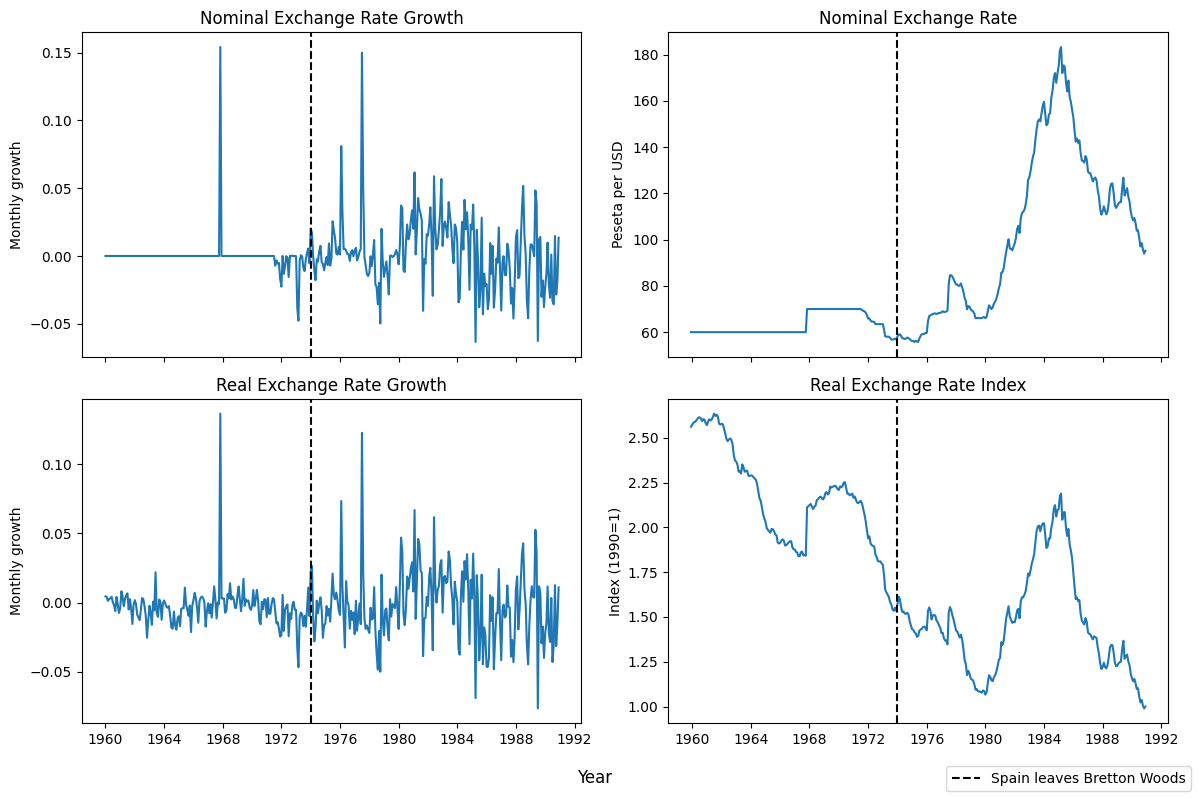

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)

# Nominal exchange rate growth
axes[0,0].plot(
    plot_df.index.get_level_values("TIME_PERIOD"),
    plot_df["nominal_exchange_rate_growth"]
)
axes[0,0].set_title("Nominal Exchange Rate Growth")
axes[0,0].set_ylabel("Monthly growth")

# Nominal exchange rate
axes[0,1].plot(
    plot_df.index.get_level_values("TIME_PERIOD"),
    plot_df["exchange_rate"]
)
axes[0,1].set_title("Nominal Exchange Rate")
axes[0,1].set_ylabel("Peseta per USD")

# Real exchange rate growth
axes[1,0].plot(
    plot_df.index.get_level_values("TIME_PERIOD"),
    plot_df["real_exchange_rate_growth"]
)
axes[1,0].set_title("Real Exchange Rate Growth")

axes[1,0].set_ylabel("Monthly growth")

# Real exchange rate index
axes[1,1].plot(
    plot_df.index.get_level_values("TIME_PERIOD"),
    plot_df["real_exchange_rate_index"]
)
axes[1,1].set_title("Real Exchange Rate Index")

axes[1,1].set_ylabel("Index (1990=1)")

# Spain left Bretton Woods system
for i, ax in enumerate(axes.flatten()):
    ax.axvline(
        pd.Timestamp("1974-01-01"),
        linestyle="--",
        color="black",
        label="Spain leaves Bretton Woods" if i == 3 else None
    )

fig.supxlabel("Year")
fig.legend(loc="lower right")
plt.tight_layout()
plt.show()

According to IMF (1972), US exited Bretton Woods system on 15/08/1971, so the following graph include until 15/08/1971

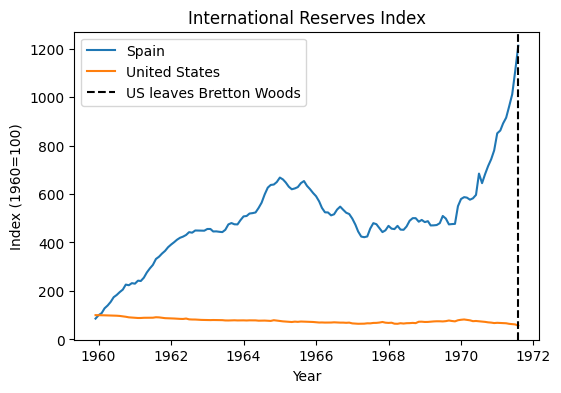

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(
    plot_df.loc["Spain"].loc[:"1971-08-01"].index,
    plot_df.loc["Spain"].loc[:"1971-08-01"]["international_reserves_index"],
    label="Spain"
)

plt.plot(
    plot_df.loc["United States"].loc[:"1971-08-01"].index,
    plot_df.loc["United States"].loc[:"1971-08-01"]["international_reserves_index"],
    label="United States"
)

plt.axvline(
        pd.Timestamp("1971-08-01"),
        linestyle="--",
        color="black",
        label="US leaves Bretton Woods"
    )

plt.title("International Reserves Index")
plt.xlabel("Year")
plt.ylabel("Index (1960=100)")

plt.legend()
plt.show()

### Section 4.2: Inflation and Industrial Production Graphs

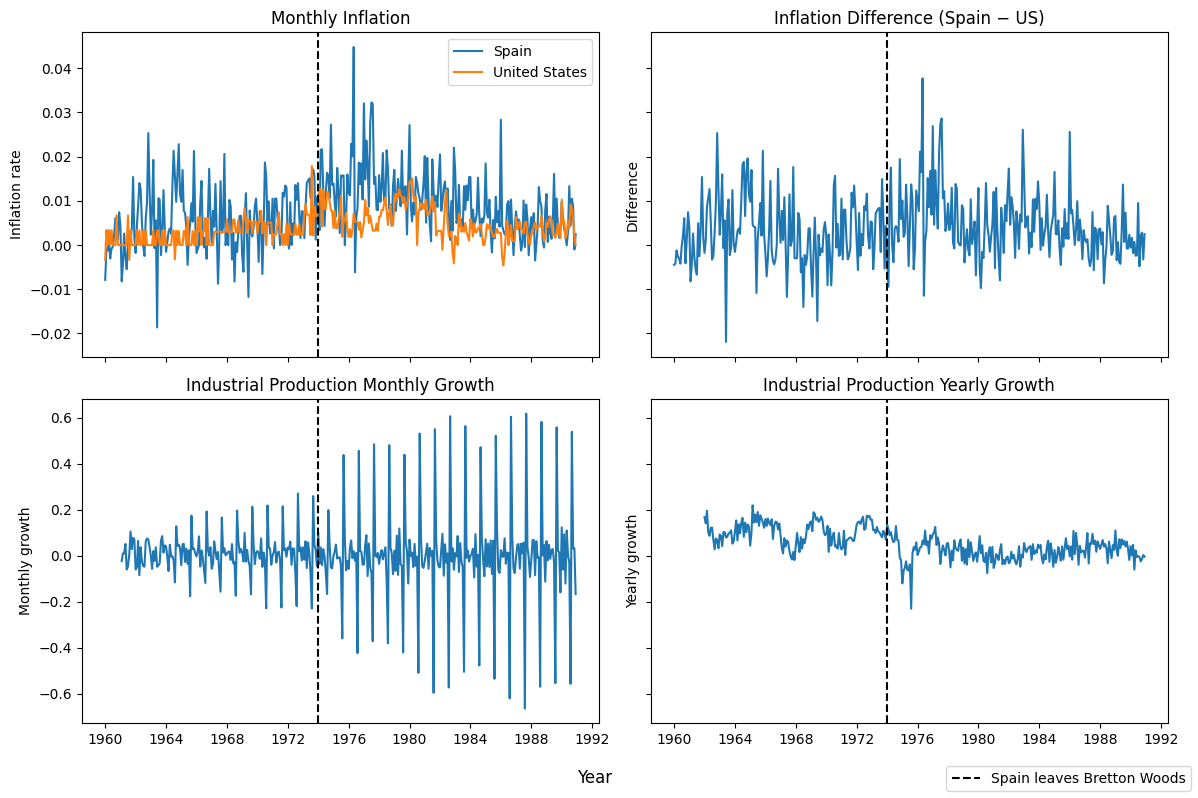

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8), sharex=True, sharey="row")

# Monthly inflation
axes[0,0].plot(
    plot_df.loc["Spain"].index,
    plot_df.loc["Spain"]["inflation"],
    label="Spain"
)

axes[0,0].plot(
    plot_df.loc["United States"].index,
    plot_df.loc["United States"]["inflation"],
    label="United States"
)

axes[0,0].set_title("Monthly Inflation")
axes[0,0].set_ylabel("Inflation rate")
axes[0,0].legend()


# Inflation difference
axes[0,1].plot(
    plot_df.loc["Spain"].index,
    plot_df.loc["Spain"]["inflation"]
    - plot_df.loc["United States"]["inflation"]
)

axes[0,1].set_title("Inflation Difference (Spain − US)")
axes[0,1].set_ylabel("Difference")


# Industrial production monthly growth
axes[1,0].plot(
    plot_df.loc["Spain"].index,
    plot_df.loc["Spain"]["industrial_production_growth_month"]
)

axes[1,0].set_title("Industrial Production Monthly Growth")
axes[1,0].set_ylabel("Monthly growth")


# Industrial production growth vs 12 months ago
axes[1,1].plot(
    plot_df.loc["Spain"].index,
    plot_df.loc["Spain"]["industrial_production_growth_year"]
)

axes[1,1].set_title("Industrial Production Yearly Growth")
axes[1,1].set_ylabel("Yearly growth")

for i, ax in enumerate(axes.flatten()):
    line = ax.axvline(
        pd.Timestamp("1974-01-01"),
        linestyle="--",
        color="black",
        label="Spain leaves Bretton Woods" if i == 3 else None
    )

fig.supxlabel("Year")
fig.legend(handles=[line], loc="lower right")

plt.tight_layout()
plt.show()

### 4.3: Comparison Statistics & Visualisation

In [ ]:
# Create new dataframe
df_new = (
    plot_df.loc["Spain"][[
        "nominal_exchange_rate_growth",
        "real_exchange_rate_growth",
        "inflation",
        "industrial_production_growth_year"
    ]]
)
df_new["inflation_difference"] = (
    plot_df.loc["Spain"]["inflation"]
    - plot_df.loc["United States"]["inflation"]
)

In [ ]:
# Separete period
before = df_new.loc[:"1971-06-01"]
after = df_new.loc["1973-03-01":]

In [ ]:
# Calculate standard deviation
std_before = before.std()
std_after = after.std()

# Calculate ratio
ratio = std_before / std_after

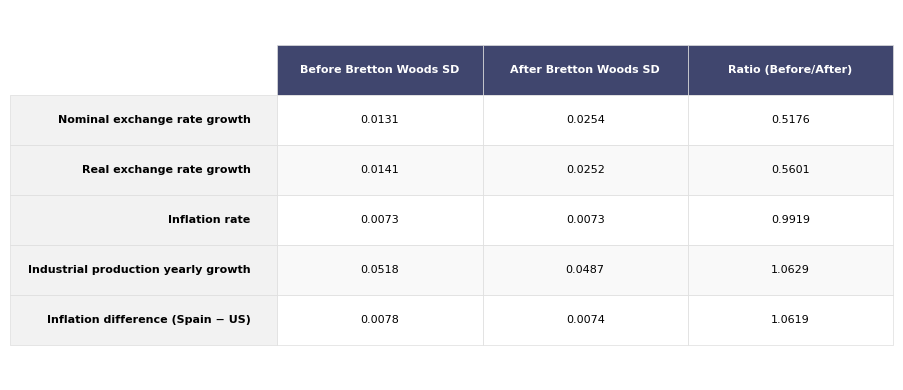

In [ ]:
# Create a table to show SD
result = pd.DataFrame({
    "Before Bretton Woods SD": std_before,
    "After Bretton Woods SD": std_after,
    "Ratio (Before/After)": ratio
})

result.index = [
    "Nominal exchange rate growth",
    "Real exchange rate growth",
    "Inflation rate",
    "Industrial production yearly growth",
    "Inflation difference (Spain − US)"
]

result = result.round(4)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=result.values,
    colLabels=result.columns,
    rowLabels=result.index,
    cellLoc='center',
    loc='center'
)

table.set_fontsize(14)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#DDDDDD')
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466e')
    elif col == -1:
        cell.set_text_props(weight='bold', ha='right')
        cell.set_facecolor('#F2F2F2')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#F9F9F9')
        else:
            cell.set_facecolor('white')

plt.tight_layout()
plt.show()

In [ ]:
plot_result = result.copy()

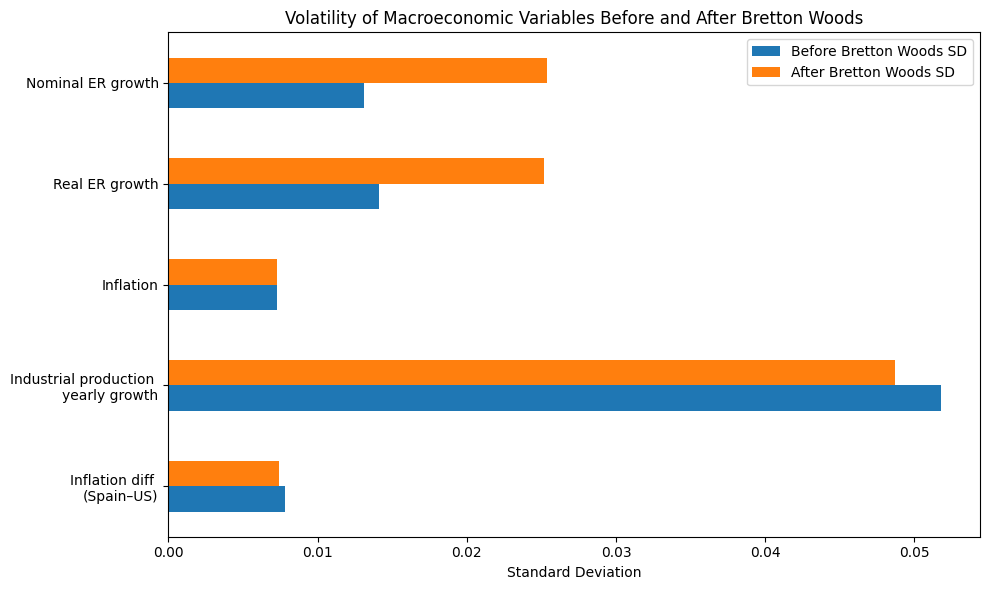

In [ ]:
# Update index for elegan chart
plot_result.index = [
    "Nominal ER growth",
    "Real ER growth",
    "Inflation",
    "Industrial production \nyearly growth",
    "Inflation diff \n(Spain–US)"
]
plot_result = plot_result.iloc[::-1]

plot_result[["Before Bretton Woods SD","After Bretton Woods SD"]].plot(
    kind="barh",
    figsize=(10,6),
)

plt.title("Volatility of Macroeconomic Variables Before and After Bretton Woods"
)
plt.xlabel("Standard Deviation")

plt.legend(["Before Bretton Woods SD","After Bretton Woods SD"])

plt.tight_layout()
plt.show()

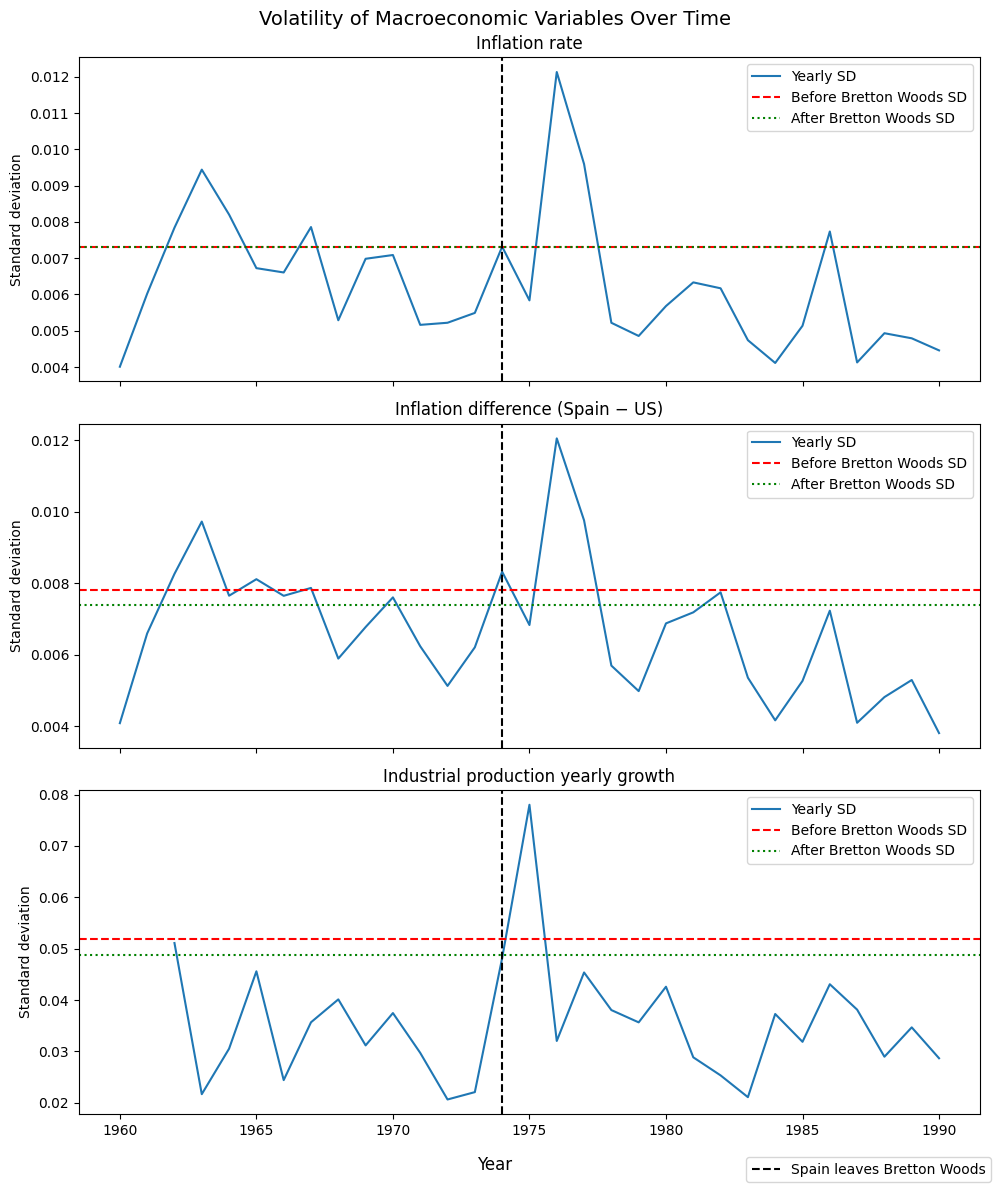

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,12), sharex=True)

variables = [
    ("inflation", "Inflation rate"),
    ("inflation_difference", "Inflation difference (Spain − US)"),
    ("industrial_production_growth_year",
     "Industrial production yearly growth")
]

for ax, (var, label) in zip(axes, variables):

    # yearly SD
    yearly_sd = df_new[var].groupby(df_new.index.year).std()

    # read from result table
    before_sd = result.loc[label, "Before Bretton Woods SD"]
    after_sd = result.loc[label, "After Bretton Woods SD"]

    # plot
    ax.plot(yearly_sd.index, yearly_sd.values, label="Yearly SD")

    ax.axhline(before_sd,
               linestyle="--",
               label="Before Bretton Woods SD",
               color="red"
    )
    ax.axhline(after_sd,
               linestyle=":",
               label="After Bretton Woods SD",
               color="green"
    )

    ax.set_title(label)
    ax.set_ylabel("Standard deviation")

    ax.legend()

for i, ax in enumerate(axes.flatten()):
    line = ax.axvline(
        1974,
        linestyle="--",
        color="black",
        label="Spain leaves Bretton Woods" if i == 2 else None
    )

fig.supxlabel("Year")
fig.legend(handles=[line], loc="lower right")

fig.suptitle(
    "Volatility of Macroeconomic Variables Over Time",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Section 4.4: Regression Analysis

## Section 5: Extensions
### Section 5.2: Black Wednesday: The UK Joining & Leaving the ERM

In [ ]:
# Get new data
temp = pd.read_csv(raw_url + "exchange_rate_uk_germany.csv")

In [ ]:
# Clean data
exchange_rate = (
    temp[["COUNTRY", "TIME_PERIOD", "OBS_VALUE"]]
    .copy()
    .rename(columns={"OBS_VALUE": "exchange_rate"})
)

In [ ]:
# Format date
exchange_rate["TIME_PERIOD"] = exchange_rate["TIME_PERIOD"].apply(
    lambda x: datetime.strptime(x, "%Y-M%m")
)

In [ ]:
exchange_rate

,COUNTRY,TIME_PERIOD,exchange_rate
0,Germany,1959-12-01,4.200000
1,Germany,1960-01-01,4.200000
2,Germany,1960-02-01,4.200000
3,Germany,1960-03-01,4.200000
4,Germany,1960-04-01,4.200000
...,...,...,...
741,United Kingdom,1990-08-01,0.526976
742,United Kingdom,1990-09-01,0.532042
743,United Kingdom,1990-10-01,0.514230
744,United Kingdom,1990-11-01,0.509196


## Section 6: Reference

International Monetary Fund (1972) *Annual report of the Executive Board for the financial year ended April 30, 1972*. Washington, D.C.: International Monetary Fund. Available at: https://www.imf.org/external/pubs/ft/ar/archive/pdf/ar1972.pdf (Accessed: 12 March 2026).

International Monetary Fund (1974) *Annual report of the Executive Board for the financial year ended April 30, 1974*. Washington, D.C.: International Monetary Fund. Available at: https://www.imf.org/external/pubs/ft/ar/archive/pdf/ar1974.pdf (Accessed: 12 March 2026).